# Experiment 5: How the Cost of Sampling Scales with Dimension

This is the last of the five experiments in Part V of the report
(`docs/reports/report_3/report.tex`, Section "Experiment 5").

**The question.** Experiment 2 showed that a standard SVM trained on enough
samples drawn from the per-example mixtures reproduces the closed-form SVM-GMU
boundary. In the plane, "enough" turned out to be about 20000 draws per example.
That raises the obvious follow-up: is the closed form merely a convenience that
saves us some sampling, or does sampling actually become impossible?

The report argues on theoretical grounds, via a concentration bound, that
sampling degrades as the dimension grows: a Gaussian, and hence a Gaussian
mixture, spreads its probability mass ever more thinly in higher dimensions, so
more and more draws are needed to represent it faithfully. This experiment turns
that argument into a measured curve.

**The quantity we measure.** For each dimension $d$ we define

$$
N^{\ast}(d) = \min\left\{N \text{ on the ladder} \;:\; \theta(N) \le \tau\right\},
$$

the smallest number of samples per example at which a standard SVM matches the
closed-form boundary to within $\tau$ degrees. If sampling really does get harder
with dimension, $N^{\ast}(d)$ should grow, and grow fast.

**What this notebook produces.** Two `.pgf` figures written into
`docs/reports/report_3/graphics/`:

| Figure | Filename | Report reference |
| --- | --- | --- |
| $N^{\ast}(d)$ against dimension | `high_dim_nstar.pgf` | Fig. `exp_high_dim_nstar` |
| Angle against dimension at a fixed budget | `high_dim_fixed_budget.pgf` | Fig. `exp_high_dim_budget` |

**Cost.** The full sweep is 7 dimensions by 30 seeds by 8 rungs of the ladder,
so 1680 standard-SVM fits, several of them on 300000-point clouds. It takes some
minutes and is cached; see Section 5.

## 0. Setup

Run this notebook from a local clone of the
[svm-gmu](https://github.com/SushrutGaikwad/svm-gmu) repository. From the
repository root:

```bash
uv sync
uv run jupyter lab
```

This notebook is **self-contained**. It defines its own dataset and every helper
it needs, and imports nothing from this repository except the `svm_gmu` library
that is the subject of the experiment.

The cell below finds the repository by walking upward from the working directory
until it sees `src/svm_gmu/__init__.py`, puts `src/` on the import path, imports
what we need, and switches matplotlib to the report's Latin Modern serif font so
the exported figures match the LaTeX document. That last step needs a working
local LaTeX (`pdflatex` with `lmodern`); comment out `use_latex_serif()` if you
do not have one.

In [1]:
import warnings
import sys
from pathlib import Path

# Locate the repository by searching upward for src/svm_gmu, then make the
# library importable from this clone (no separate install needed).
repo_root = None
for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (base / "src" / "svm_gmu" / "__init__.py").exists():
        repo_root = base
        break
if repo_root is None:
    raise RuntimeError(
        "Could not find the svm-gmu repository. Run this notebook from a local "
        "clone, for example `uv run jupyter lab` from the repository root."
    )

src_dir = str(repo_root / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty, use_latex_serif

# Render every figure with the report's LaTeX serif font, for both the inline
# preview and the saved .pgf. Comment out if you have no local LaTeX.
use_latex_serif()
matplotlib.rcParams["font.size"] = 10

# Where the report expects this experiment's figures.
GRAPHICS_DIR = repo_root / "docs" / "reports" / "report_3" / "graphics"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

print("repository:", repo_root)
print("figures go to:", GRAPHICS_DIR)

repository: D:\Jobs\USA\UB\Volunteer Research Assistant\Aerospace\svm-gmu
figures go to: D:\Jobs\USA\UB\Volunteer Research Assistant\Aerospace\svm-gmu\docs\reports\report_3\graphics


## 1. Why this experiment needs its own dataset

Experiments 1 to 4 all share the planar `close_separable` dataset. This one
cannot use it, and the reason is worth stating because it is a real constraint
rather than a convenience.

The banana and crescent shapes that motivate SVM-GMU are **intrinsically
low-dimensional**. We could embed them in $\mathbb{R}^{50}$ by padding with noise
coordinates, but that would be a cheat: the signal would still live in a
two-dimensional subspace, and the sampler's job would be no harder than it was
in the plane. The measurement would then say nothing about dimension.

So we build a purpose-made family of datasets, one per dimension, in which the
uncertainty genuinely fills all $d$ coordinates.

### The construction

For each $d$ we build $n = 10$ examples, five per class. Example $i$ is an
equally weighted mixture of $M = 3$ isotropic Gaussians,

$$
f_{\mathbf{x}_i}(\mathbf{x})
= \sum_{m=1}^{3} \frac{1}{3}\,
  \mathcal{N}\!\left(\mathbf{x};\; \boldsymbol{\mu}_i^{(m)},\; \sigma^{2}\mathbf{I}_d\right),
\qquad
\boldsymbol{\mu}_i^{(m)} = \mathbf{c}_i + s\,\mathbf{u}_i^{(m)},
$$

where $\mathbf{c}_i$ is the example's centre, each $\mathbf{u}_i^{(m)}$ is an
independent random **unit vector** (a direction of length one) and $s$ is the
component spread. In words: start at the centre and step a distance $s$ along a
random direction to place each of the three components.

Unpacking the two pieces of jargon:

- A covariance $\sigma^{2}\mathbf{I}_d$, a number times the identity, is
  **isotropic**: the same variance in every coordinate and no correlation
  between them. Each component is a round fuzzy ball of radius about $\sigma$,
  not a stretched ellipse.
- A **unit vector** is just a direction. Multiplying it by $s$ places the
  component's centre a distance $s$ from $\mathbf{c}_i$ along that direction.

So each example is three round balls of uncertainty scattered a short hop apart
in three random directions of $\mathbb{R}^{d}$ and blended in equal thirds.

The two class centres are separated by $\pm\delta$ along the first coordinate and
given a small isotropic jitter in the remaining ones, so the optimal boundary
tilts through all $d$ axes instead of lining up with a single one. We use
$\delta = 2$, jitter standard deviation $0.5$, $s = 0.9$ and $\sigma = 1.1$. The
classes are deliberately close enough that their uncertainty overlaps, so the
boundary depends on the full distributions and not merely the observed means.

Two properties make this the right construction for the question:

1. It is **genuinely high-dimensional**: there is variance $\sigma^{2}$ in every
   one of the $d$ directions and the optimal weight vector uses all of them.
2. It is a **genuine mixture** ($M = 3 > 1$), so the closed-form reference is
   literally SVM-GMU rather than its single-Gaussian special case.

In high dimensions a three-component mixture is only mildly non-Gaussian, and
that is deliberate. The value of the mixture's *shape* is what Experiments 1 and
3 demonstrate, in the plane, where non-Gaussian structure lives. This experiment
is measuring something else: the dimensional scaling of the sampling cost.

## 2. Building one, and looking at it

The construction is easiest to trust if we build it at $d = 2$ first, where it
can be drawn. Ten examples, five per class, each a trio of round balls.

In [2]:
demo_rng = np.random.default_rng(0)

SEPARATION = 2.0     # class-centre offset along the first axis
JITTER = 0.5         # off-axis jitter, so the boundary is genuinely d-dimensional
SPREAD = 0.9         # how far each component sits from its example centre
SIGMA = 1.1          # per-component isotropic standard deviation

X_demo, y_demo, uncertainty_demo, centres_demo = [], [], [], []
for class_label in (1.0, -1.0):
    for _ in range(5):
        centre = JITTER * demo_rng.standard_normal(2)
        centre[0] += class_label * SEPARATION

        # Three random directions, each rescaled to length one.
        directions = demo_rng.standard_normal((3, 2))
        directions /= np.linalg.norm(directions, axis=1, keepdims=True)

        means = centre + SPREAD * directions
        covariances = np.stack([SIGMA**2 * np.eye(2) for _ in range(3)])

        uncertainty_demo.append({
            "weights": np.full(3, 1.0 / 3.0),
            "means": means,
            "covariances": covariances,
        })
        centres_demo.append(centre)
        X_demo.append(means.mean(axis=0))     # the example's observed mean
        y_demo.append(class_label)

X_demo = np.array(X_demo)
y_demo = np.array(y_demo)

print("examples:", X_demo.shape, " labels:", y_demo)
print("first example's centre:        ", np.round(centres_demo[0], 3))
print("first example's component means:\n", np.round(uncertainty_demo[0]["means"], 3))

# Every component should sit exactly SPREAD away from its example's centre,
# since it was placed by stepping that far along a unit direction.
distances = np.linalg.norm(uncertainty_demo[0]["means"] - centres_demo[0], axis=1)
print("distances from centre:", np.round(distances, 6),
      " (all equal to SPREAD =", SPREAD, ")")

examples: (10, 2)  labels: [ 1.  1.  1.  1.  1. -1. -1. -1. -1. -1.]
first example's centre:         [ 2.063 -0.066]
first example's component means:
 [[2.951 0.079]
 [1.317 0.437]
 [2.791 0.463]]
distances from centre: [0.9 0.9 0.9]  (all equal to SPREAD = 0.9 )


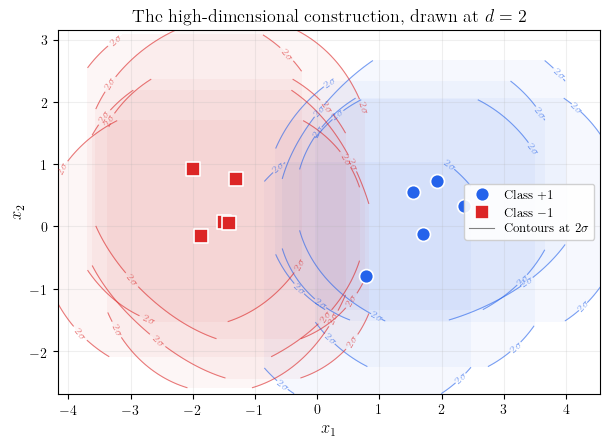

In [3]:
fig, ax = plot_uncertainty(
    X_demo, y_demo, uncertainty_demo,
    sigmas=(2,),
    figsize=(7, 6),
    title="The high-dimensional construction, drawn at $d = 2$",
)
plt.show()

The two classes clearly overlap, which is the point: if they were cleanly
separated, the boundary would not depend on the uncertainty and the experiment
would measure nothing. Each example is a slightly lumpy blob rather than a
banana, which is the deliberate trade discussed above.

Now the reusable version, for any $d$.

In [4]:
def make_highdim_dataset(d, rng, n_per_class=5, n_components=3,
                         sep=2.0, jitter=0.5, spread=0.9, sigma=1.1):
    """Build a genuinely d-dimensional GMM-per-example dataset with two close classes."""
    X, y, uncertainty = [], [], []
    for class_label in (1.0, -1.0):
        for _ in range(n_per_class):
            centre = jitter * rng.standard_normal(d)
            centre[0] += class_label * sep
            directions = rng.standard_normal((n_components, d))
            directions /= np.linalg.norm(directions, axis=1, keepdims=True)
            means = centre + spread * directions
            uncertainty.append({
                "weights": np.full(n_components, 1.0 / n_components),
                "means": means,
                "covariances": np.stack(
                    [sigma**2 * np.eye(d) for _ in range(n_components)]
                ),
            })
            X.append(means.mean(axis=0))
            y.append(class_label)
    return np.array(X), np.array(y), uncertainty


def draw_from_gmm(gmm, n_samples, rng):
    """Draw n_samples independent points from one Gaussian mixture."""
    weights, means, covariances = gmm["weights"], gmm["means"], gmm["covariances"]
    n_components, d = means.shape
    which_component = rng.choice(n_components, size=n_samples, p=weights)
    points = np.empty((n_samples, d))
    for m in range(n_components):
        mask = which_component == m
        if mask.any():
            points[mask] = rng.multivariate_normal(
                means[m], covariances[m], size=int(mask.sum())
            )
    return points

## 3. Measuring disagreement without a grid

Experiment 2 compared boundaries partly by evaluating both decision functions on
a dense $60 \times 60$ grid. That is hopeless here: a grid with 60 points per
axis would need $60^{50}$ points at $d = 50$.

Two of the three metrics survive unchanged, because they never needed a grid:

$$
\theta = \arccos\!\left(\hat{\mathbf{w}}_{A}^{\intercal}\hat{\mathbf{w}}_{B}\right),
\qquad
\Delta^{\text{offset}}
= \left|\frac{b_A}{\lVert\mathbf{w}_A\rVert} - \frac{b_B}{\lVert\mathbf{w}_B\rVert}\right| .
$$

The third one we replace with a **Monte Carlo** version of the same idea. Rather
than covering the whole space uniformly, which is both impossible and pointless
in high dimensions, we evaluate the two decision functions where the data
actually lives: on a cloud of $G = 10 \times 2000 = 20000$ points drawn from the
per-example mixtures themselves.

$$
\Delta^{\text{mc}}
= \sqrt{\frac{1}{G}\sum_{g=1}^{G}
\left(\hat{f}_A(\mathbf{x}_g) - \hat{f}_B(\mathbf{x}_g)\right)^{2}},
\qquad
\hat{f}(\mathbf{x}) = \hat{\mathbf{w}}^{\intercal}\mathbf{x} + \frac{b}{\lVert\mathbf{w}\rVert} .
$$

As before, the unit normalization is what makes $\hat{f}$ the genuine signed
distance to the boundary and therefore comparable between two classifiers.

The headline result uses the angle, since it is the metric with an obvious
tolerance to threshold against.

In [5]:
def boundary_metrics(w_a, b_a, w_b, b_b, points):
    """Return (angle in degrees, offset difference, RMS) between two boundaries."""
    a_hat = w_a / np.linalg.norm(w_a)
    b_hat = w_b / np.linalg.norm(w_b)
    angle = np.degrees(np.arccos(np.clip(np.dot(a_hat, b_hat), -1.0, 1.0)))
    offset_a = b_a / np.linalg.norm(w_a)
    offset_b = b_b / np.linalg.norm(w_b)
    rms = np.sqrt(
        np.mean(((points @ a_hat + offset_a) - (points @ b_hat + offset_b)) ** 2)
    )
    return float(angle), float(abs(offset_a - offset_b)), float(rms)

## 4. One dimension, one seed, step by step

Before the sweep, let us walk through a single cell of it at $d = 5$ so the loop
below is unsurprising.

The closed-form reference costs nothing extra as $d$ grows: SVM-GMU consumes the
analytic mixtures directly and never samples, so it is exact at every dimension.
That is the whole asymmetry this experiment is built to expose.

In [6]:
walkthrough_rng = np.random.default_rng(11)

X_5, y_5, uncertainty_5 = make_highdim_dataset(5, walkthrough_rng)

# The closed-form reference: exact, no sampling.
reference = SvmGmu(lam=0.01, max_iter=1000, batch_size=len(X_5), random_state=42)
reference.fit(X_5, y_5, sample_uncertainty=uncertainty_5)
w_reference = reference.coef_.copy()
b_reference = float(reference.intercept_)

# The evaluation cloud for the Monte Carlo RMS.
evaluation_cloud = np.vstack(
    [draw_from_gmm(gmm, 2000, walkthrough_rng) for gmm in uncertainty_5]
)

print("d = 5, n =", len(X_5), "examples")
print("reference w =", np.round(w_reference, 4))
print("reference b =", round(b_reference, 4))
print("evaluation cloud:", evaluation_cloud.shape)

d = 5, n = 10 examples
reference w = [ 1.3891  0.0765 -0.1166 -0.019  -0.0511]
reference b = 0.1387
evaluation cloud: (20000, 5)


In [7]:
# The sampling competitor, at two budgets, to see the trend inside one cell.
for N in (100, 3000):
    parts_X, parts_y = [], []
    for gmm, label in zip(uncertainty_5, y_5):
        parts_X.append(draw_from_gmm(gmm, N, walkthrough_rng))
        parts_y.append(np.full(N, label, dtype=np.float64))
    X_cloud = np.vstack(parts_X)
    y_cloud = np.concatenate(parts_y)

    n_total = X_cloud.shape[0]
    sampled = SvmGmu(
        lam=0.01,
        max_iter=max(2000, 500 * int(np.log10(max(n_total, 10)) + 1)),
        batch_size=min(256, n_total),
        random_state=42,
    )
    sampled.fit(X_cloud, y_cloud)

    angle, offset_difference, mc_rms = boundary_metrics(
        sampled.coef_, float(sampled.intercept_),
        w_reference, b_reference, evaluation_cloud,
    )
    print(f"N = {N:>5d}  (n_total = {n_total:>6d})   angle = {angle:6.3f} deg   "
          f"offset = {offset_difference:.4f}   MC RMS = {mc_rms:.4f}")

N =   100  (n_total =   1000)   angle =  8.002 deg   offset = 0.0098   MC RMS = 0.1768


N =  3000  (n_total =  30000)   angle =  0.738 deg   offset = 0.0135   MC RMS = 0.0203


Already at $d = 5$ the sampler needs thousands of draws per example to get within
a couple of degrees, where in the plane a few hundred sufficed. The sweep
quantifies that across dimensions.

## 5. The full sweep

For each dimension and each of 30 seeds we build a **fresh dataset**, fit the
exact reference, and then climb a geometric ladder of sample budgets, that is, a
sequence whose values grow by a roughly constant multiplicative factor, here
about $\times 3$ per rung, so eight rungs span three and a half orders of
magnitude.

Note that each seed redraws the dataset as well as the samples. That is
deliberate: we want the result to describe the *construction*, not one
particular random arrangement of ten examples.

**About the cache.** This is 1680 standard-SVM fits, the largest on 300000
points. The result is cached to `experiments/.cache/` (git-ignored). Set
`FORCE_RECOMPUTE = True` to recompute and overwrite it.

When loading the cache we pick out the dimensions in `D_VALUES` by name rather
than plotting whatever the file happens to contain, and raise a clear error if
any of them are missing. That keeps the figures determined by this notebook,
so a cache left over from an earlier run with a different ladder of dimensions
cannot quietly change what gets plotted.

In [8]:
FORCE_RECOMPUTE = False
CACHE = repo_root / "experiments" / ".cache" / "high_dim_gmm_full.npz"

D_VALUES = [2, 3, 5, 10, 20, 35, 50]
N_LADDER = [10, 30, 100, 300, 1000, 3000, 10000, 30000]

seed_sequence = np.random.SeedSequence(2026)
seeds = [int(child.generate_state(1)[0]) for child in seed_sequence.spawn(30)]

if CACHE.exists() and not FORCE_RECOMPUTE:
    cached = np.load(CACHE)
    cached_dimensions = [int(value) for value in cached["d_values"]]
    missing = [d for d in D_VALUES if d not in cached_dimensions]
    if missing:
        raise RuntimeError(
            f"cache {CACHE.name} has no results for d = {missing}. "
            f"Set FORCE_RECOMPUTE = True to rebuild it."
        )
    # Keep only the dimensions this experiment reports: the cache may hold
    # extra ones left over from exploratory runs.
    keep = [cached_dimensions.index(d) for d in D_VALUES]
    d_values = cached["d_values"][keep]
    n_ladder = cached["n_ladder"]
    angle = cached["angle"][keep]        # shape (n_dimensions, n_seeds, n_rungs)
    offset = cached["offset"][keep]
    rms = cached["rms"][keep]
    print(f"loaded cache {CACHE.name} (holds d = {cached_dimensions})")
    if len(keep) != len(cached_dimensions):
        print(f"using the reported subset d = {D_VALUES}")
else:
    shape = (len(D_VALUES), len(seeds), len(N_LADDER))
    angle = np.full(shape, np.nan)
    offset = np.full(shape, np.nan)
    rms = np.full(shape, np.nan)

    for d_index, d in enumerate(D_VALUES):
        for seed_index, seed in enumerate(seeds):
            rng = np.random.default_rng(seed)

            # A fresh dataset for this (d, seed), and its exact reference.
            X_d, y_d, uncertainty_d = make_highdim_dataset(d, rng)
            reference = SvmGmu(
                lam=0.01, max_iter=1000, batch_size=len(X_d), random_state=42
            )
            reference.fit(X_d, y_d, sample_uncertainty=uncertainty_d)
            w_ref = reference.coef_.copy()
            b_ref = float(reference.intercept_)

            evaluation_cloud = np.vstack(
                [draw_from_gmm(gmm, 2000, rng) for gmm in uncertainty_d]
            )

            for rung_index, N in enumerate(N_LADDER):
                parts_X, parts_y = [], []
                for gmm, label in zip(uncertainty_d, y_d):
                    parts_X.append(draw_from_gmm(gmm, N, rng))
                    parts_y.append(np.full(N, label, dtype=np.float64))
                X_cloud = np.vstack(parts_X)
                y_cloud = np.concatenate(parts_y)

                n_total = X_cloud.shape[0]
                sampled = SvmGmu(
                    lam=0.01,
                    max_iter=max(2000, 500 * int(np.log10(max(n_total, 10)) + 1)),
                    batch_size=min(256, n_total),
                    random_state=42,
                )
                sampled.fit(X_cloud, y_cloud)

                (angle[d_index, seed_index, rung_index],
                 offset[d_index, seed_index, rung_index],
                 rms[d_index, seed_index, rung_index]) = boundary_metrics(
                    sampled.coef_, float(sampled.intercept_),
                    w_ref, b_ref, evaluation_cloud,
                )
            print(f"d={d:>3d} seed={seed}: angle at largest N = "
                  f"{angle[d_index, seed_index, -1]:.3f}")

    d_values = np.array(D_VALUES)
    n_ladder = np.array(N_LADDER, dtype=float)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(CACHE, d_values=d_values, n_ladder=n_ladder,
             seeds=np.array(seeds), angle=angle, offset=offset, rms=rms)
    print(f"wrote cache {CACHE.name}")

print("angle array shape (dimensions, seeds, ladder rungs):", angle.shape)

loaded cache high_dim_gmm_full.npz (holds d = [2, 3, 5, 10, 20, 35, 50])
angle array shape (dimensions, seeds, ladder rungs): (7, 30, 8)


## 6. Reading off $N^{\ast}(d)$

For one dimension and one seed, $N^{\ast}$ is the first rung of the ladder whose
angle falls at or below the tolerance. If no rung ever does, the seed hit the
ceiling and we record it as missing (`nan`) rather than pretending it reached
some value. Those seeds are what the upward triangles mark on the figure.

We use two tolerances, a lenient $\tau = 2^{\circ}$ and a strict
$\tau = 1^{\circ}$, and report the median across seeds.

In [9]:
ceiling = n_ladder[-1]

nstar = {}
for tau in (1.0, 2.0):
    values = np.full((len(d_values), len(seeds)), np.nan)
    for d_index in range(len(d_values)):
        for seed_index in range(len(seeds)):
            reached = np.where(angle[d_index, seed_index, :] <= tau)[0]
            if reached.size:
                values[d_index, seed_index] = n_ladder[reached[0]]
    nstar[tau] = values

# nanmedian warns when every seed at a dimension failed to reach the tolerance;
# that is a meaningful outcome here, not an error, so we silence the warning.
print(f"{'d':>4s}  {'N* (tau = 2 deg)':>18s}  {'N* (tau = 1 deg)':>18s}")
print("-" * 44)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for d_index, d in enumerate(d_values):
        cells_out = []
        for tau in (2.0, 1.0):
            median = np.nanmedian(nstar[tau][d_index])
            n_failed = int(np.isnan(nstar[tau][d_index]).sum())
            if np.isnan(median):
                cells_out.append(f"> {int(ceiling)}")
            elif n_failed > 0:
                cells_out.append(f"{int(median)} ({n_failed} over cap)")
            else:
                cells_out.append(f"{int(median)}")
        print(f"{int(d):>4d}  {cells_out[0]:>18s}  {cells_out[1]:>18s}")

   d    N* (tau = 2 deg)    N* (tau = 1 deg)
--------------------------------------------
   2                  30                 300
   3                 300                2000
   5                1000                3000
  10                3000  10000 (15 over cap)
  20               10000             > 30000
  35  30000 (12 over cap)             > 30000
  50             > 30000             > 30000


The growth is steep and orderly: roughly an order of magnitude of extra sampling
for every doubling of the dimension. The `over cap` counts show the wall being
approached before it is hit. At $\tau = 2^{\circ}$, $d = 35$ still reports a
median of 30000, but 12 of the 30 seeds never got there at all, so the median is
already being propped up by the better half of the runs. By $d = 50$ all 30 fail.
At the strict $\tau = 1^{\circ}$ the wall arrives sooner: half the seeds are
already over the cap at $d = 10$, and by $d = 20$ every one of them is.

This is why the median alone would flatter the sampler, and why the table above
reports the failures next to it rather than quietly dropping them.

The closed-form SVM-GMU, meanwhile, attains the exact boundary at every $d$ from
the ten examples and their mixture descriptions, with no sampling at all.

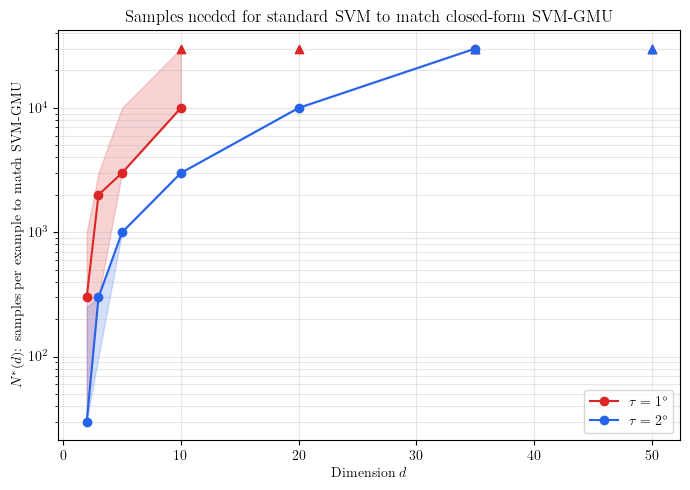

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {1.0: "#dc2626", 2.0: "#2563eb"}

for tau in (1.0, 2.0):
    values = nstar[tau]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        median = np.nanmedian(values, axis=1)
        lower = np.nanpercentile(values, 25, axis=1)
        upper = np.nanpercentile(values, 75, axis=1)
    ax.plot(d_values, median, marker="o", color=colors[tau],
            label=rf"$\tau = {tau:g}^\circ$")
    ax.fill_between(d_values, lower, upper, color=colors[tau], alpha=0.2)

    # Mark dimensions where at least one seed never reached the tolerance.
    exceeded = np.isnan(values).any(axis=1)
    if exceeded.any():
        ax.scatter(d_values[exceeded], np.full(exceeded.sum(), ceiling),
                   marker="^", color=colors[tau], zorder=5)

ax.set_yscale("log")
ax.set_xlabel(r"Dimension $d$")
ax.set_ylabel(r"$N^\ast(d)$: samples per example to match SVM-GMU")
ax.set_title("Samples needed for standard SVM to match closed-form SVM-GMU")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig(GRAPHICS_DIR / "high_dim_nstar.pgf", backend="pgf", bbox_inches="tight")
plt.show()

## 7. The complementary view: fix the budget, watch the error grow

$N^{\ast}(d)$ asks how much sampling a fixed accuracy costs. The mirror-image
question is how much accuracy a fixed sampling budget buys, which is closer to
the situation of someone with a fixed compute budget deciding what to run.

We take two budgets from the ladder, $N = 1000$ and $N = 10^{4}$, and plot the
median angle against dimension. The dashed line at $0^{\circ}$ is the closed-form
SVM-GMU, which is exact at every dimension and therefore flat by definition.

N =   1000:  median angle from 0.59 deg at d = 2 to 6.93 deg at d = 50
N =  10000:  median angle from 0.27 deg at d = 2 to 2.91 deg at d = 50


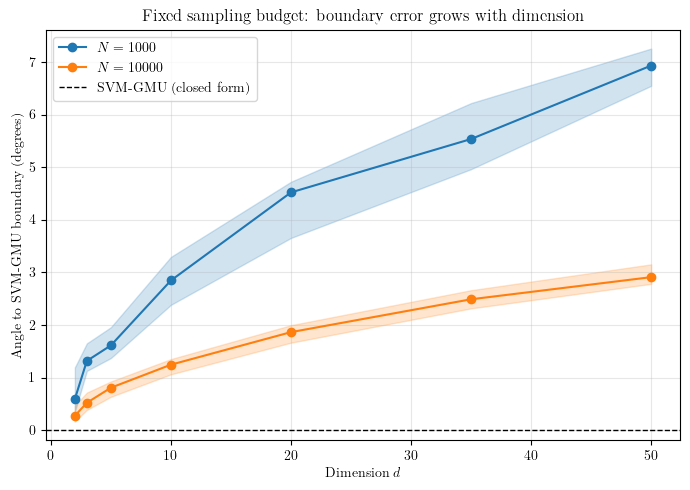

In [11]:
ladder_list = [float(value) for value in n_ladder]

fig, ax = plt.subplots(figsize=(7, 5))
for budget in (1000, 10000):
    rung_index = ladder_list.index(float(budget))
    median = np.nanmedian(angle[:, :, rung_index], axis=1)
    lower = np.nanpercentile(angle[:, :, rung_index], 25, axis=1)
    upper = np.nanpercentile(angle[:, :, rung_index], 75, axis=1)
    line, = ax.plot(d_values, median, marker="o", label=rf"$N = {budget}$")
    ax.fill_between(d_values, lower, upper, color=line.get_color(), alpha=0.2)
    print(f"N = {budget:>6d}:  median angle from {median[0]:.2f} deg at d = "
          f"{int(d_values[0])} to {median[-1]:.2f} deg at d = {int(d_values[-1])}")

ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0,
           label="SVM-GMU (closed form)")
ax.set_xlabel(r"Dimension $d$")
ax.set_ylabel("Angle to SVM-GMU boundary (degrees)")
ax.set_title("Fixed sampling budget: boundary error grows with dimension")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig(GRAPHICS_DIR / "high_dim_fixed_budget.pgf",
            backend="pgf", bbox_inches="tight")
plt.show()

## 8. Interpretation

**Why the sampler struggles.** The closed-form reference uses the analytic
mixtures directly and incurs no sampling error at any $d$. The standard SVM must
reconstruct each example's $d$-dimensional distribution from finitely many
draws. As $d$ grows there are more directions in which the empirical cloud can
fail to pin the boundary down, and the mixture's mass spreads more thinly across
all of them, so the number of draws needed to reach a fixed angular tolerance
grows steeply. This is precisely the difficulty the concentration bound in the
report anticipates.

**What that means in practice.** Sampling from the per-example distributions and
training a standard SVM is a viable substitute for the closed-form objective
*only in low dimensions*. By a few dozen dimensions, even 30000 samples per
example are not enough to reach two-degree agreement. SVM-GMU sidesteps the
issue entirely by evaluating the expected hinge loss in closed form, at a cost
that is independent of any sampling and, for diagonal or isotropic covariances,
scales only as $\mathcal{O}(M_i\,d)$ per example.

In genuinely high-dimensional problems this is the difference between a
tractable fit and an infeasible one, and high-dimensional problems are precisely
where uncertainty-aware classification tends to be needed: the features that
carry real measurement uncertainty, such as embeddings, spectra and pipeline
outputs, are rarely two-dimensional.

**A caveat on what was measured.** The tolerance $\tau$ is a choice, and the
ladder is coarse, spaced about $\times 3$ per rung, so $N^{\ast}$ is only
resolved to within a factor of three. Both figures should be read as
order-of-magnitude statements about *scaling*, which is what the question was,
rather than as precise sample-size recommendations.

One asymmetry is worth naming rather than glossing over. A seed that never
reaches the tolerance has no finite $N^{\ast}$ at all, so it cannot enter the
median; the median is taken over the seeds that succeeded, and the triangles
mark the dimensions where some did not. That makes the plotted curve an
*optimistic* estimate wherever triangles appear, because it is averaging the
runs that worked and setting aside the ones that did not. At $d = 35$ under
$\tau = 2^{\circ}$, where 12 of 30 seeds ran out of ladder, the true cost is
therefore worse than the plotted 30000. The bias runs in the direction that
favours the sampling approach, which means the conclusion of this experiment
survives it.